# Cluster Analysis exercise

In [73]:
import pandas as pd

In [74]:
# Load the data
df = pd.read_csv('german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [75]:
# Rename the 'Unnamed: 0' index column to 'ID'
df = df.rename(columns={'Unnamed: 0': 'ID'})
df.head()

,ID,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [76]:
# Check for missing values in all variables
missing_values = df.isnull().sum()
missing_values_df = pd.DataFrame(missing_values, columns=['Missing Values'])

# Display the missing values count
missing_values_df

,Missing Values
ID,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [77]:
# Fill missing values with 'unknown' since they represent the absence of an account
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')

# Verify that missing values have been filled
print("Missing values after filling:\n", df[['Saving accounts', 'Checking account']].isnull().sum())

Missing values after filling:
 Saving accounts     0
Checking account    0
dtype: int64


In [78]:
# Summary of data types
print("Data Types:\n", df.dtypes)

Data Types:
 ID                  int64
Age                 int64
Sex                   str
Job                 int64
Housing               str
Saving accounts       str
Checking account      str
Credit amount       int64
Duration            int64
Purpose               str
dtype: object


In [79]:
# Basic statistics for numerical columns
df.describe()

,ID,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


## Exploratory Data Analysis (EDA)

Visualizing distributions, counts, relationships, and correlations.

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

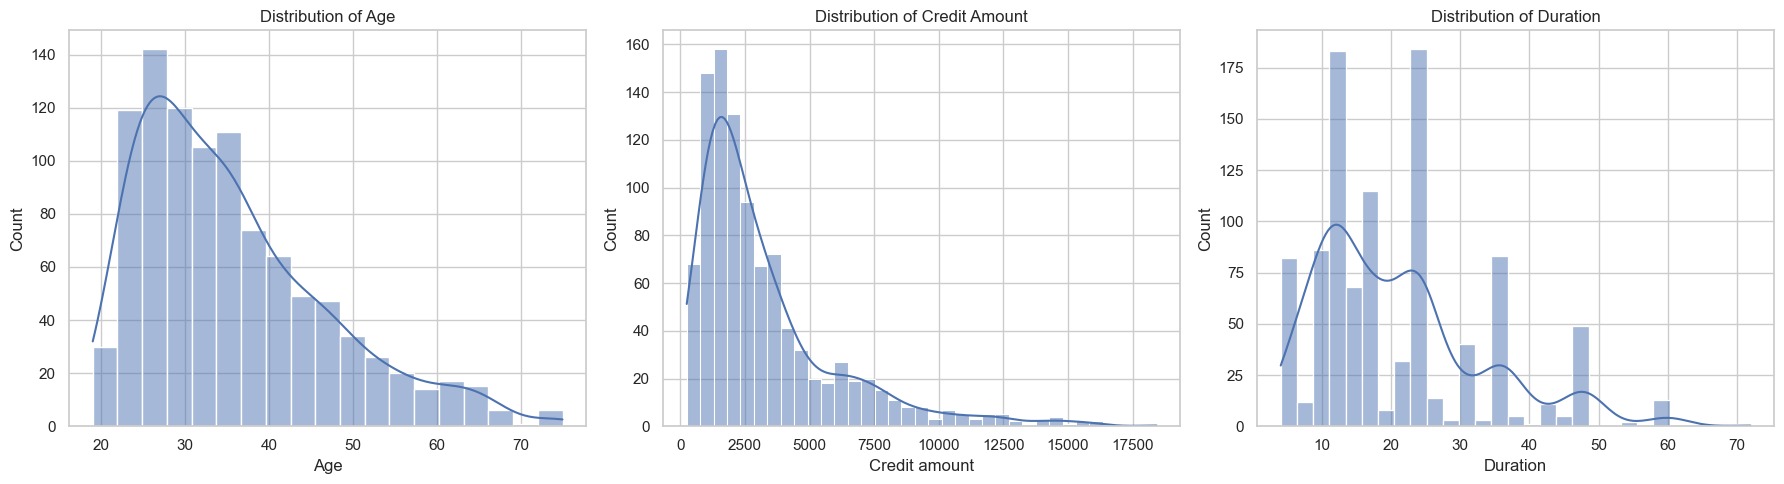

In [81]:
# 1. Visualize the distribution of 'Age', 'Credit amount', and 'Duration'
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age')

sns.histplot(df['Credit amount'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Credit Amount')

sns.histplot(df['Duration'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Duration')

plt.tight_layout()
plt.show()

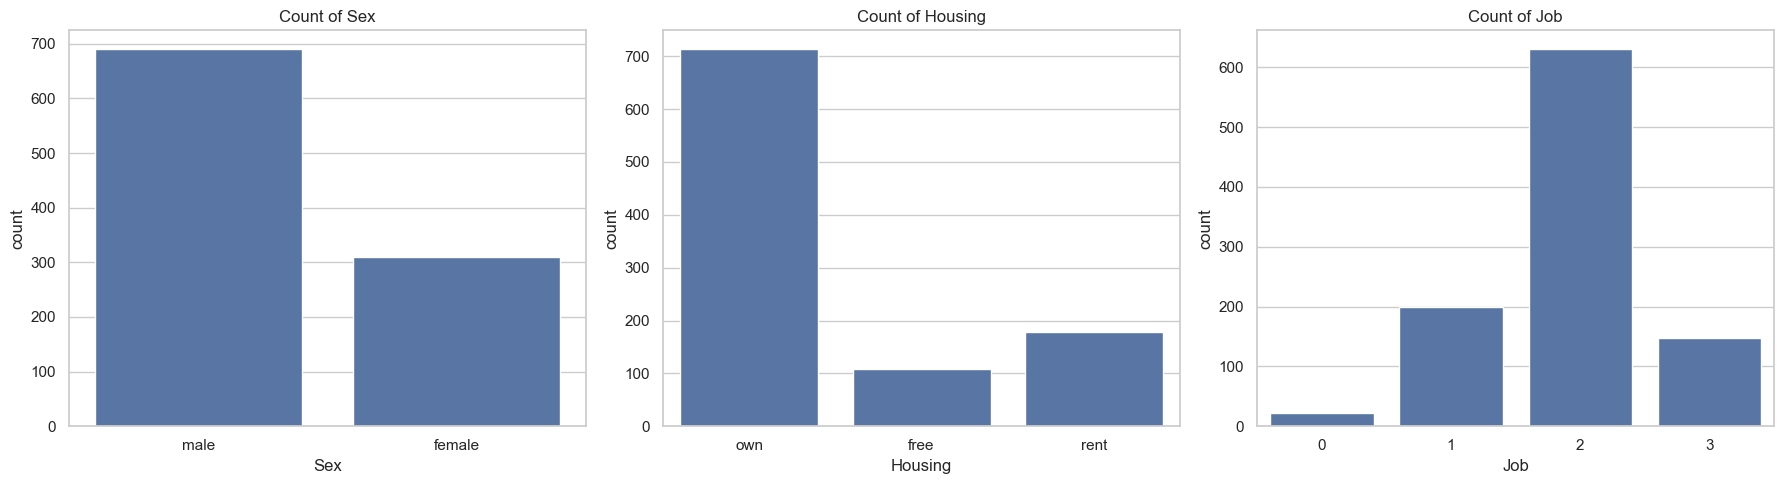

In [82]:
# 2. Create bar charts to show the count of 'Sex', 'Housing', and 'Job'
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Sex', ax=axes[0])
axes[0].set_title('Count of Sex')

sns.countplot(data=df, x='Housing', ax=axes[1])
axes[1].set_title('Count of Housing')

sns.countplot(data=df, x='Job', ax=axes[2])
axes[2].set_title('Count of Job')

plt.tight_layout()
plt.show()

/var/folders/rp/vldf0xqd7rz1kcxdp15y37bm0000gp/T/ipykernel_13661/922545946.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Checking account', palette='Set2')


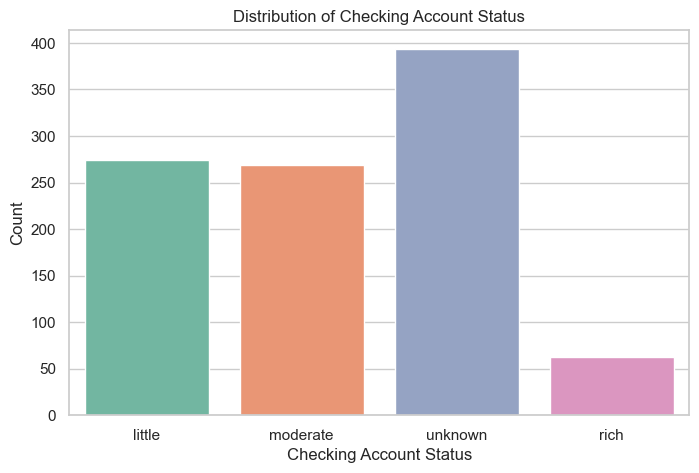

/var/folders/rp/vldf0xqd7rz1kcxdp15y37bm0000gp/T/ipykernel_13661/922545946.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Saving accounts', palette='Set2')


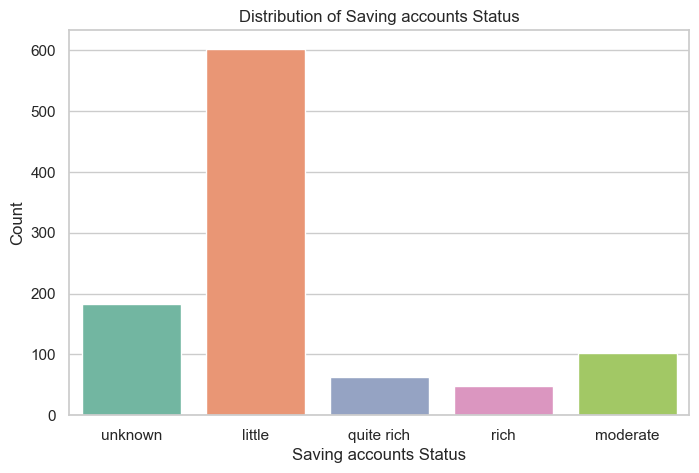

In [83]:
# Distribution of 'Checking account' variable
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Checking account', palette='Set2')
plt.title('Distribution of Checking Account Status')
plt.xlabel('Checking Account Status')
plt.ylabel('Count')
plt.show()


# Distribution of 'Saving accounts' variable
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Saving accounts', palette='Set2')
plt.title('Distribution of Saving accounts Status')
plt.xlabel('Saving accounts Status')
plt.ylabel('Count')
plt.show()

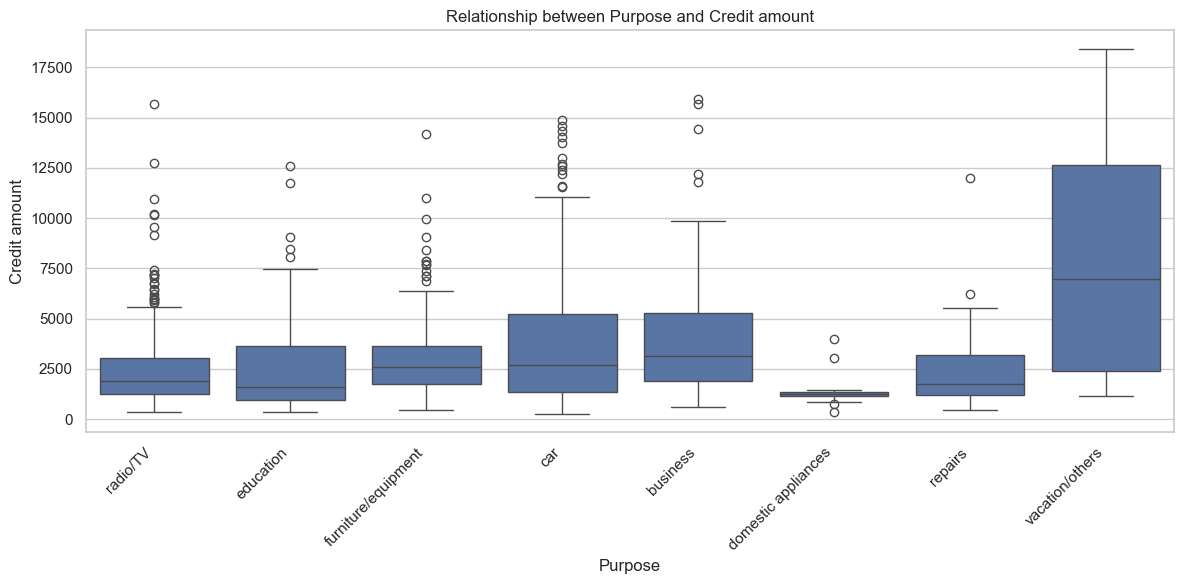

In [84]:
# 3. Use a boxplot to examine the relationship between 'Purpose' and 'Credit amount'
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Purpose', y='Credit amount')
plt.title('Relationship between Purpose and Credit amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

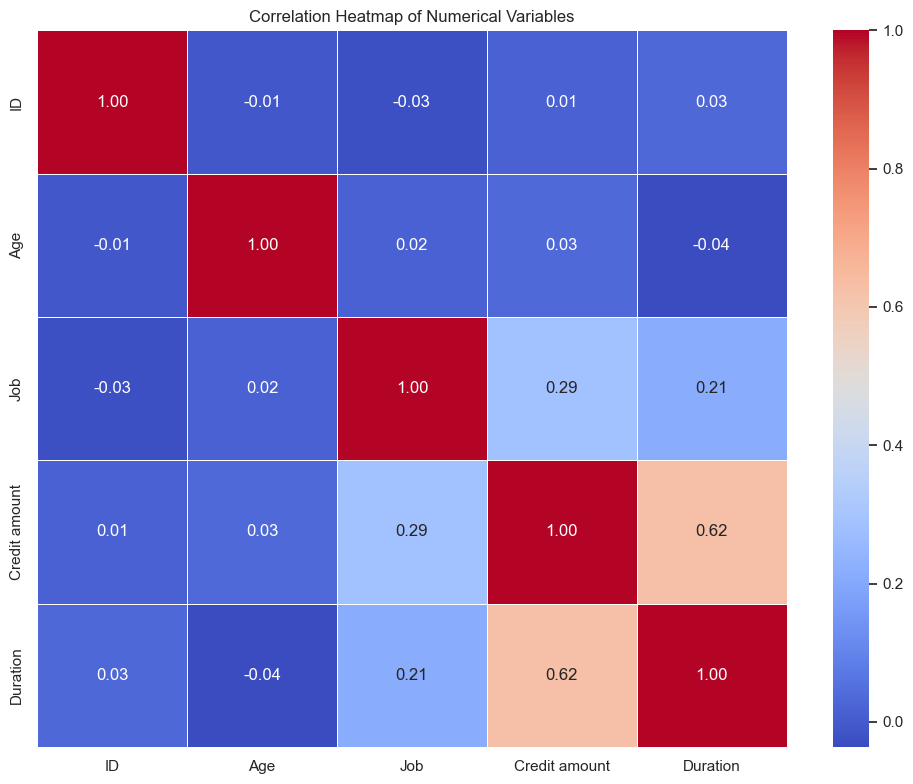

In [85]:
# 4. Generate a correlation heatmap for the numerical variables
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numerical_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

The correlation heatmap reveals a generally weak to moderate correlation structure among the numerical variables, which is a positive sign for the upcoming Cluster Analysis. Most variable pairs exhibit near-zero correlation, ensuring that these features provide distinct, non-redundant information to the clustering algorithm.

The most notable observation is the moderate positive correlation ($r = 0.62$) between Credit amount and Duration. This is logically expected, as higher credit amounts often require longer repayment periods. While this value is not high enough to cause severe 'double counting' issues (typically a concern when $r > 0.70$ or $0.80$), it indicates a slight overlap in the variance explained by these two features.

## Prepare Data for Cluster Analysis

Encoding categorical variables and scaling the features for algorithms like K-Means that are sensitive to distances.

In [86]:
from sklearn.preprocessing import StandardScaler

# 1. Encode categorical variables using One-Hot Encoding
categorical_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Drop the 'ID' column as it's an identifier, not a feature for clustering
if 'ID' in df_encoded.columns:
    df_features = df_encoded.drop('ID', axis=1)
else:
    df_features = df_encoded.copy()

# 2. Apply StandardScaler to the features
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns)

# 3. Display the first few rows of the transformed dataframe
df_scaled.head()

,Age,Job,Credit amount,Duration,Sex_male,Housing_own,Housing_rent,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,...,Checking account_moderate,Checking account_rich,Checking account_unknown,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,2.766456,0.146949,-0.745131,-1.236478,0.670280,0.634448,-0.466933,-0.338862,-0.259299,-0.224544,...,-0.606621,-0.259299,-0.806328,-0.712949,-0.110208,-0.250398,-0.470108,1.603567,-0.149983,-0.110208
1,-1.191404,0.146949,0.949817,2.248194,-1.491914,0.634448,-0.466933,-0.338862,-0.259299,-0.224544,...,1.648476,-0.259299,-0.806328,-0.712949,-0.110208,-0.250398,-0.470108,1.603567,-0.149983,-0.110208
2,1.183312,-1.383771,-0.416562,-0.738668,0.670280,0.634448,-0.466933,-0.338862,-0.259299,-0.224544,...,-0.606621,-0.259299,1.240190,-0.712949,-0.110208,3.993639,-0.470108,-0.623610,-0.149983,-0.110208
3,0.831502,0.146949,1.634247,1.750384,0.670280,-1.576173,-0.466933,-0.338862,-0.259299,-0.224544,...,-0.606621,-0.259299,-0.806328,-0.712949,-0.110208,-0.250398,2.127172,-0.623610,-0.149983,-0.110208
4,1.535122,0.146949,0.566664,0.256953,0.670280,-1.576173,-0.466933,-0.338862,-0.259299,-0.224544,...,-0.606621,-0.259299,-0.806328,1.402626,-0.110208,-0.250398,-0.470108,-0.623610,-0.149983,-0.110208


## K-Means Cluster Analysis

1. Determine the optimal number of clusters using the **Elbow Method** and **Silhouette Score** (testing K from 2 to 10).
2. Fit the K-Means model with the chosen number of clusters.
3. Visualize the clusters with a 2D scatter plot colored by cluster ID.

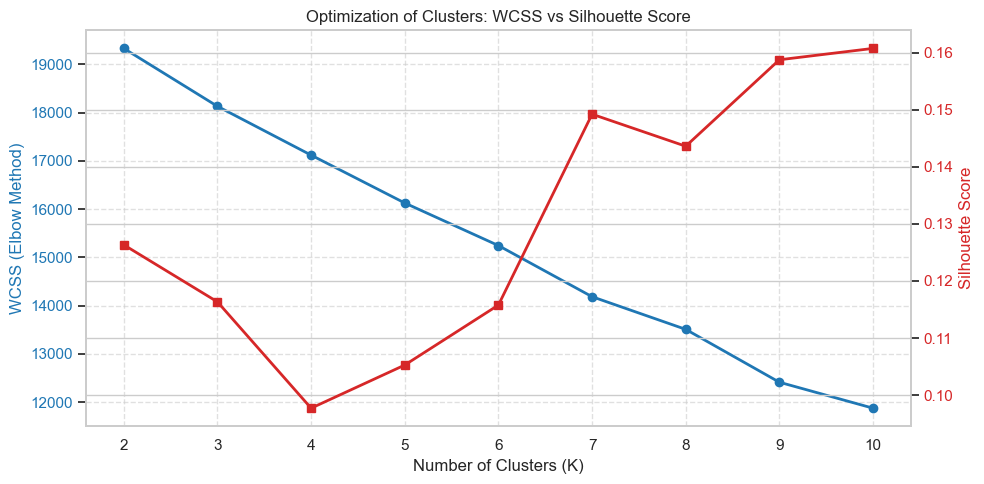

In [87]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X = df_scaled.values

wcss = [] 
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    
    # L'attributo .inertia_ restituisce il valore del WCSS
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Plotting Elbow Method (WCSS) and Silhouette Score
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS (Elbow Method)', color=color)
ax1.plot(K_range, wcss, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)  
ax2.plot(K_range, silhouette_scores, marker='s', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimization of Clusters: WCSS vs Silhouette Score')
fig.tight_layout()
plt.show()

In [88]:
# Based on the Elbow and Silhouette plots, we choose an optimal K, K=3. 
# In this case there is no clear "elbow", but with K=3 we have a relative max 
# for silhouette score without reaching K=7 that, with only 1000 observations, is too high

optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X)

# Add 'Cluster' label column to the original dataframe
df['Cluster'] = clusters
df_encoded['Cluster'] = clusters

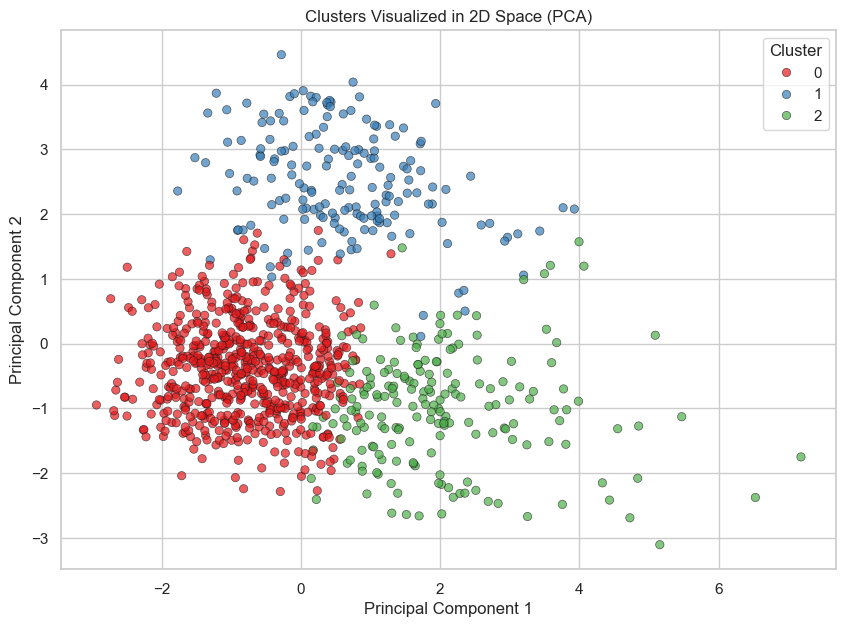

In [89]:
from sklearn.decomposition import PCA

# PCA for 2D Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='Set1', alpha=0.7, edgecolor='k')
plt.title('Clusters Visualized in 2D Space (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

## Cluster Analysis & Profiling

We can now analyze the resulting clusters by calculating the means of numerical features and the modes of categorical features.

In [90]:
# Mean values for numerical features
numeric_summary = df.groupby('Cluster')[['Age', 'Credit amount', 'Duration', 'Job']].mean()
print("--- Numerical Features (Mean) ---")
display(numeric_summary)

# Mode values for categorical features
categorical_summary = df.groupby('Cluster')[['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']].agg(lambda x: pd.Series.mode(x)[0])
print("\n--- Categorical Features (Mode) ---")
display(categorical_summary)

--- Numerical Features (Mean) ---


,Age,Credit amount,Duration,Job
Cluster,,,,
0,36.525237,2162.859621,16.799685,1.801262
1,30.161850,2865.739884,18.346821,1.832370
2,37.155440,7275.813472,36.673575,2.305699



--- Categorical Features (Mode) ---


,Sex,Housing,Saving accounts,Checking account,Purpose
Cluster,,,,,
0,male,own,little,unknown,radio/TV
1,female,rent,little,little,car
2,male,own,little,moderate,car


### Cluster Profiles Summary (K=3)

Based on the K-Means clustering analysis, we identified 3 distinct customer segments:

**Cluster 0: The Mature Tech-Enthusiast**
- **Demographics:** Primarily older males (average age ~36.5) who own their home.
- **Financial Behavior:** This group requests the lowest credit amounts (~2,162) and maintains the shortest repayment durations (~16.8 months).
- **Purpose:** Their primary reason for credit is radio/TV, suggesting lifestyle upgrades or consumer electronics.
- **Risk Profile:** Likely a lower-risk segment due to home ownership and conservative loan amounts, even if their checking account status is often "unknown."

**Cluster 1: The Young Renter & Commuter**
- **Demographics:** Mostly younger females (average age ~30) who typically rent their housing.
- **Financial Behavior:** They borrow moderate amounts (~2,865) over relatively short periods (~18.3 months). Their job level is similar to Cluster 0.
- **Purpose:** Driven by necessity, specifically purchasing a car.
- **Risk Profile:** Moderate risk. Being younger and renting implies less stability than Cluster 0, and they have "little" in both savings and checking accounts, indicating tighter liquidity.

**Cluster 2: The High-Stake Long-Term Investor**
- **Demographics:** Primarily older males (average age ~37) who own their home, but with a higher Job score (~2.3), indicating more specialized or senior employment.
- **Financial Behavior:** This is the "heavy-hitter" group. They request very high credit amounts (~7,275) with the longest durations (~36.7 months).
- **Purpose:** Largely focused on car loans, but at a much higher price point (likely luxury or business vehicles).
- **Risk Profile:** Higher exposure. While they have "moderate" checking account levels, the sheer size and duration of the loans represent a significant commitment.

## Hierarchical Clustering

In addition to K-Means, we perform Agglomerative Hierarchical Clustering. We start by plotting a dendrogram using Ward's linkage method to evaluate the distances between merged clusters.

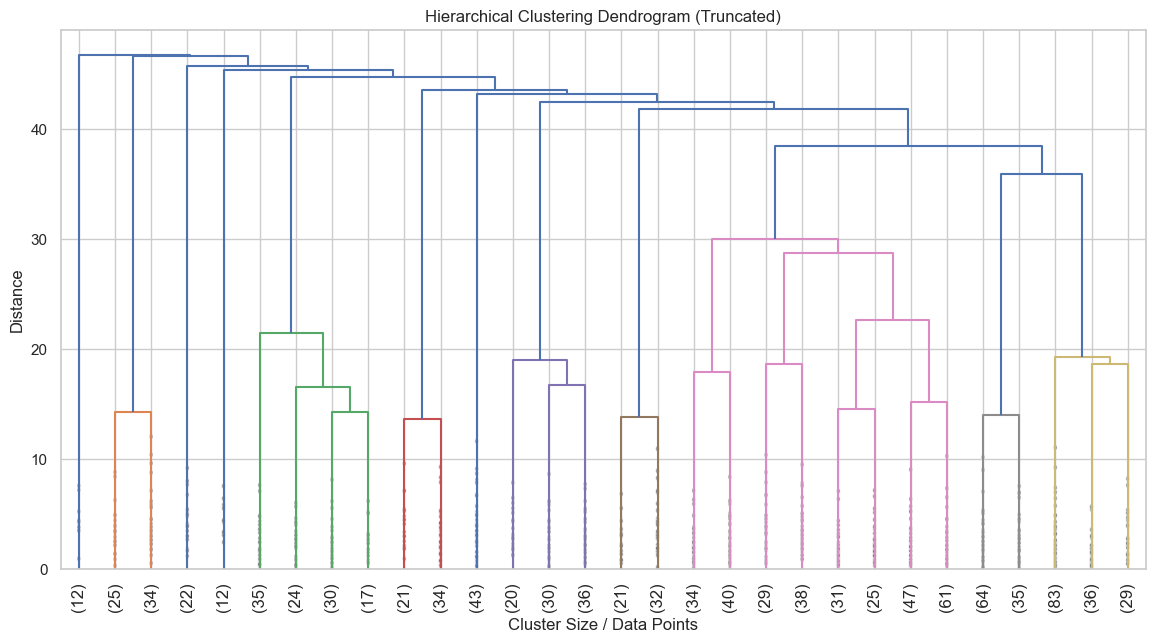

In [91]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.title("Hierarchical Clustering Dendrogram (Truncated)")

# Compute the linkage matrix using Ward's method
linked = linkage(df_scaled, method='ward')

# We plot a truncated dendrogram to make it readable
dendrogram(
    linked,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=30,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True
)
plt.xlabel("Cluster Size / Data Points")
plt.ylabel("Distance")
plt.show()

### Fit Model & Compare with K-Means

We fit the `AgglomerativeClustering` model using the same number of clusters (`optimal_k = 3`) and compare the labels against the previously assigned K-Means clusters using a cross-tabulation and a heatmap.

--- Cross-Tabulation: K-Means vs Hierarchical ---


Hierarchical,0,1,2
K-Means,,,
0,598,0,36
1,164,0,9
2,167,12,14


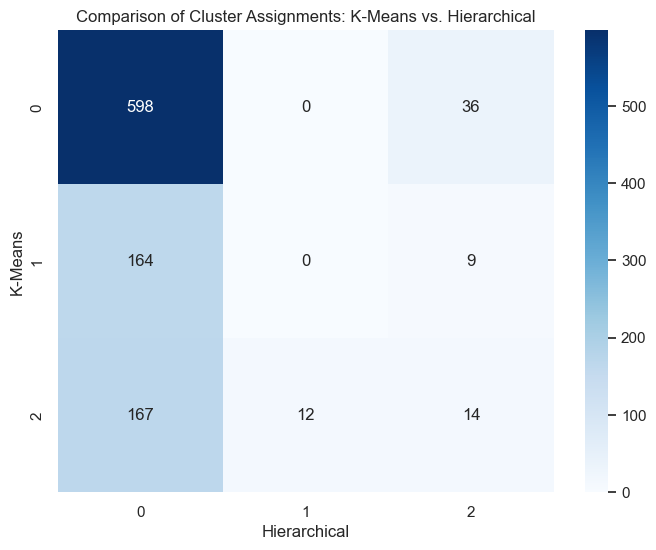

In [92]:
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns

# Fit the model
agg_model = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df['Hierarchical_Cluster'] = agg_model.fit_predict(df_scaled)

# Create a cross-tabulation to see the overlap between the two clustering results
comparison = pd.crosstab(df['Cluster'], df['Hierarchical_Cluster'], 
                         rownames=['K-Means'], 
                         colnames=['Hierarchical'])

print("--- Cross-Tabulation: K-Means vs Hierarchical ---")
display(comparison)

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(comparison, annot=True, fmt='d', cmap='Blues')
plt.title('Comparison of Cluster Assignments: K-Means vs. Hierarchical')
plt.show()

In [93]:
# Profiling for Hierarchical Clusters
hierarchical_numeric_profile = df.groupby('Hierarchical_Cluster')[['Age', 'Credit amount', 'Duration', 'Job']].mean()
print("--- Hierarchical Cluster Profile: Numerical Variables (Mean) ---")
display(hierarchical_numeric_profile)

hierarchical_categorical_profile = df.groupby('Hierarchical_Cluster')[['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']].agg(lambda x: pd.Series.mode(x)[0])
print("\n--- Hierarchical Cluster Profile: Categorical Variables (Mode) ---")
display(hierarchical_categorical_profile)

print("\n--- Hierarchical Cluster Summary ---")
print("By observing these mean and mode values, we can profile each hierarchical cluster.")
print("The cross-tabulation table from the previous step highlights how these align with the K-Means segments.")

--- Hierarchical Cluster Profile: Numerical Variables (Mean) ---


,Age,Credit amount,Duration,Job
Hierarchical_Cluster,,,,
0,35.315393,3232.371367,20.833154,1.899892
1,39.916667,8209.333333,32.333333,2.500000
2,38.288136,2879.203390,19.677966,1.847458



--- Hierarchical Cluster Profile: Categorical Variables (Mode) ---


,Sex,Housing,Saving accounts,Checking account,Purpose
Hierarchical_Cluster,,,,,
0,male,own,little,unknown,car
1,male,own,little,moderate,vacation/others
2,male,own,little,unknown,education



--- Hierarchical Cluster Summary ---
By observing these mean and mode values, we can profile each hierarchical cluster.
The cross-tabulation table from the previous step highlights how these align with the K-Means segments.
